# Ajustando distribuições a dados reais

**Tema:** Estatística › Distribuições de Probabilidade

Os notebooks anteriores foram no sentido **modelo → dados**: escolhemos a
distribuição e simulamos. Aqui vamos no sentido que importa no trabalho:
**dados → modelo**. Você recebe uma coluna e precisa decidir o que ela é.

O processo tem quatro etapas, e vamos executá-las em três conjuntos de dados
com naturezas diferentes:

1. **Olhar** — histograma, ECDF, escala log, estatísticas-resumo.
2. **Hipotetizar** — de que mecanismo esses dados poderiam ter vindo?
3. **Ajustar** — estimar os parâmetros (máxima verossimilhança).
4. **Criticar** — QQ-plot, teste de aderência, comparação por AIC.

> **Aviso que vale o notebook inteiro:** nenhum dado real segue exatamente uma
> distribuição teórica. A pergunta nunca é "é log-normal?" (a resposta é
> sempre não), e sim "a log-normal é boa o bastante para a decisão que preciso
> tomar?".

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(2718)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Três conjuntos de dados "de campo"

Vamos gerar os dados com mecanismos realistas — e depois **esquecer** como eles
foram gerados, para fazer o diagnóstico honestamente.

In [2]:
N = 8_000

# (A) Latência de um endpoint HTTP em milissegundos.
#     Mecanismo real: um tempo-base de processamento + ocasional retry/GC.
latencia = np.concatenate([
    rng.lognormal(np.log(45), 0.45, int(N * 0.93)),      # caminho feliz
    rng.lognormal(np.log(320), 0.60, int(N * 0.07)),     # retry / coleta de lixo
])
rng.shuffle(latencia)

# (B) Nº de chamados abertos por cliente no trimestre.
#     Mecanismo real: clientes têm propensões diferentes (heterogeneidade).
propensao = rng.gamma(shape=0.8, scale=2.5, size=N)
chamados = rng.poisson(propensao)

# (C) Tempo até a falha de um componente, em horas.
#     Mecanismo real: desgaste progressivo.
falha = stats.weibull_min.rvs(c=2.2, scale=1800, size=N, random_state=7)

dados = {"Latência (ms)": latencia, "Chamados/trimestre": chamados,
         "Horas até falha": falha}

for nome, v in dados.items():
    print(f"\n{nome}")
    print(f"   n = {len(v):,}  |  média = {v.mean():.2f}  |  mediana = {np.median(v):.2f}")
    print(f"   dp = {v.std(ddof=1):.2f}  |  assimetria = {stats.skew(v):.2f}  "
          f"|  curtose exc. = {stats.kurtosis(v):.2f}")
    print(f"   min = {v.min():.2f}  |  p95 = {np.percentile(v, 95):.2f}  "
          f"|  max = {v.max():.2f}  |  % zeros = {(v == 0).mean():.1%}")


Latência (ms)
   n = 8,000  |  média = 73.31  |  mediana = 47.06
   dp = 108.57  |  assimetria = 5.82  |  curtose exc. = 45.63
   min = 9.51  |  p95 = 226.89  |  max = 1845.65  |  % zeros = 0.0%

Chamados/trimestre
   n = 8,000  |  média = 1.99  |  mediana = 1.00
   dp = 2.61  |  assimetria = 2.26  |  curtose exc. = 7.59
   min = 0.00  |  p95 = 7.00  |  max = 26.00  |  % zeros = 36.7%

Horas até falha
   n = 8,000  |  média = 1589.09  |  mediana = 1515.30
   dp = 760.96  |  assimetria = 0.49  |  curtose exc. = -0.08
   min = 29.07  |  p95 = 2945.13  |  max = 4816.01  |  % zeros = 0.0%


## 2. Etapa 1 — olhar antes de calcular

Três painéis por variável: escala natural, escala log, e ECDF. É o mínimo.

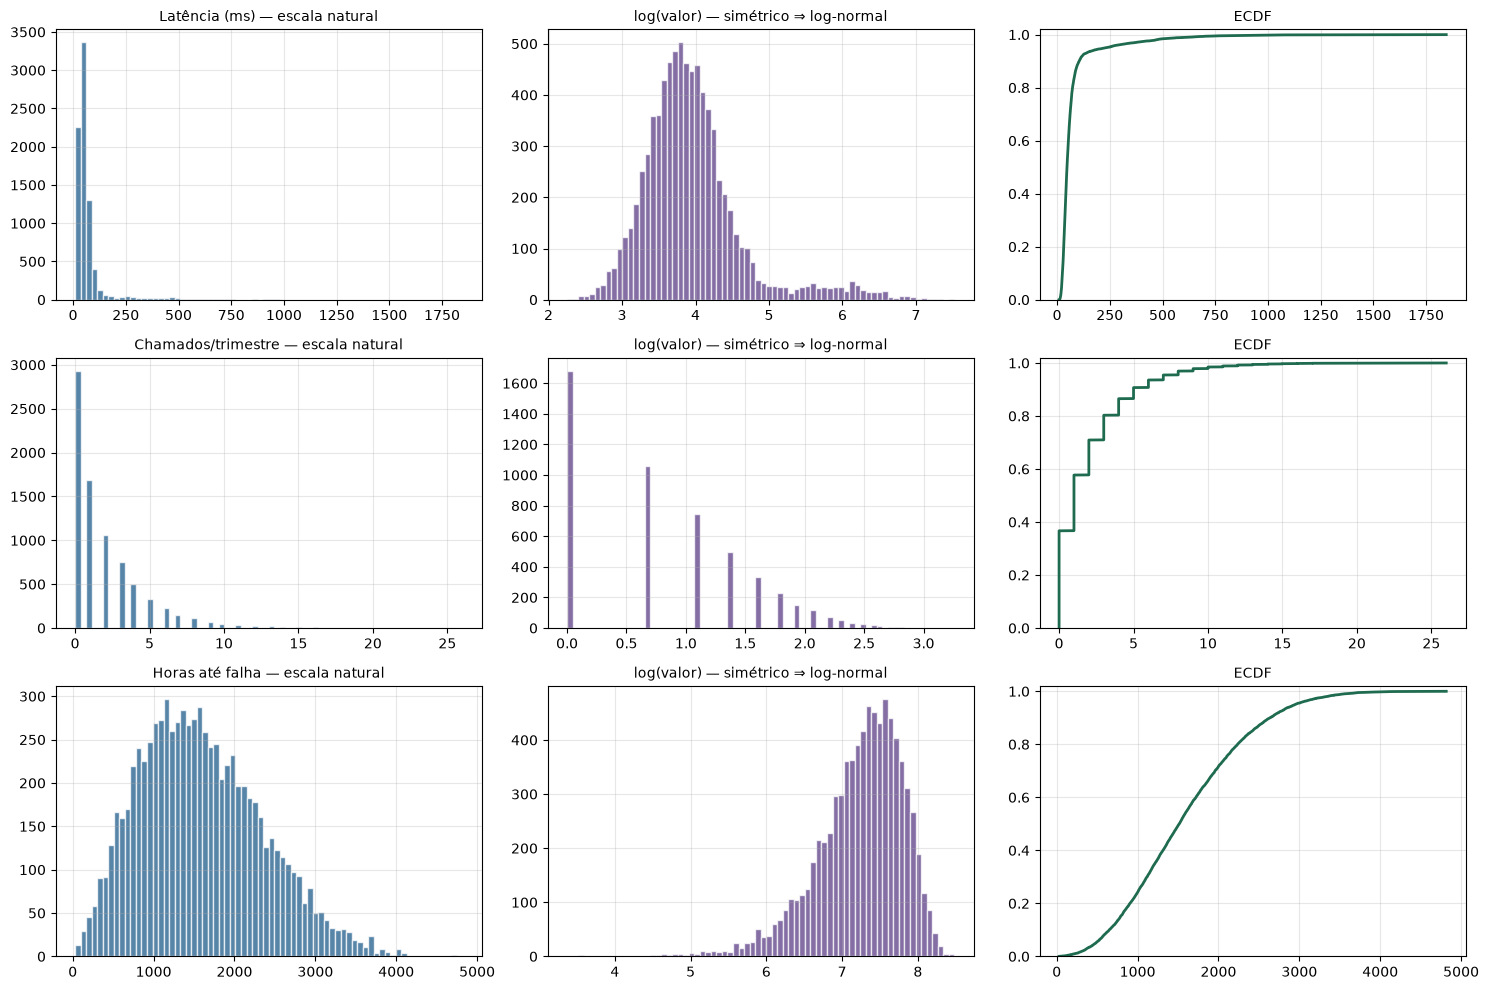

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for linha, (nome, v) in enumerate(dados.items()):
    positivos = v[v > 0]

    axes[linha, 0].hist(v, bins=70, color=AZUL, alpha=0.75, edgecolor="white")
    axes[linha, 0].set_title(f"{nome} — escala natural", fontsize=10)

    axes[linha, 1].hist(np.log(positivos), bins=70, color=ROXO, alpha=0.75,
                        edgecolor="white")
    axes[linha, 1].set_title("log(valor) — simétrico ⇒ log-normal", fontsize=10)

    ordenado = np.sort(v)
    axes[linha, 2].plot(ordenado, np.arange(1, len(v) + 1) / len(v),
                        lw=2, color=VERDE)
    axes[linha, 2].set_title("ECDF", fontsize=10)
    axes[linha, 2].set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

Leitura dos painéis do meio (o log):

* **Latência:** quase simétrico, mas com um "ombro" à direita — sinal de
  **mistura** de dois regimes, não de uma log-normal pura.
* **Chamados:** discreto e com muitos zeros; o log nem é aplicável direito.
  Sinal claro de **contagem**, não de contínua.
* **Horas até falha:** assimétrico à **esquerda** no log — a cauda direita é
  curta demais para log-normal. Sinal de **Weibull com $k>1$**.

## 3. Etapa 2+3 — hipotetizar e ajustar por máxima verossimilhança

O `scipy.stats` tem `.fit()` para praticamente toda distribuição. Ele maximiza
a verossimilhança numericamente. Vamos comparar candidatas de forma
sistemática, usando o **AIC** como critério.

$$\text{AIC} = 2k - 2\ln \hat{L}$$

onde $k$ é o número de parâmetros e $\hat{L}$ a verossimilhança maximizada.
**Menor AIC é melhor.** O termo $2k$ é a penalidade por complexidade: um modelo
com mais parâmetros precisa compensar com ganho real de ajuste.

In [4]:
def compara_distribuicoes(amostra, candidatas, nome_dados):
    """Ajusta cada candidata por MLE e ranqueia por AIC.

    `floc=0` fixa o parâmetro de locação em zero — obrigatório para dados
    estritamente positivos, senão o scipy 'desliza' a distribuição e o ajuste
    perde sentido físico (um tempo de falha não pode começar em -37).
    """
    linhas = []
    for nome, dist in candidatas.items():
        try:
            if dist in (stats.lognorm, stats.weibull_min, stats.gamma, stats.expon):
                params = dist.fit(amostra, floc=0)
            else:
                params = dist.fit(amostra)
            log_veros = np.sum(dist.logpdf(amostra, *params))
            k = len(params)
            aic = 2 * k - 2 * log_veros
            ks = stats.kstest(amostra, dist.cdf, args=params).statistic
            linhas.append({"distribuição": nome, "AIC": aic,
                           "log-verossimilhança": log_veros,
                           "nº params": k, "KS": ks, "params": np.round(params, 4)})
        except Exception as exc:
            linhas.append({"distribuição": nome, "AIC": np.nan,
                           "log-verossimilhança": np.nan, "nº params": np.nan,
                           "KS": np.nan, "params": f"falhou: {exc}"})
    tabela = pd.DataFrame(linhas).sort_values("AIC").reset_index(drop=True)
    tabela["ΔAIC"] = tabela["AIC"] - tabela["AIC"].min()
    print(f"\n=== {nome_dados} ===")
    print(tabela[["distribuição", "AIC", "ΔAIC", "KS", "nº params"]]
          .to_string(index=False, float_format=lambda x: f"{x:,.2f}"))
    return tabela


continuas = {
    "Log-normal": stats.lognorm,
    "Weibull": stats.weibull_min,
    "Gama": stats.gamma,
    "Exponencial": stats.expon,
    "Normal": stats.norm,
}

tab_latencia = compara_distribuicoes(latencia, continuas, "Latência (ms)")
tab_falha = compara_distribuicoes(falha, continuas, "Horas até falha")


=== Latência (ms) ===
distribuição       AIC      ΔAIC   KS  nº params
  Log-normal 79,767.05      0.00 0.11          3
        Gama 83,826.42  4,059.37 0.20          3
     Weibull 84,627.34  4,860.30 0.18          3
 Exponencial 84,719.26  4,952.21 0.21          2
      Normal 97,704.76 17,937.71 0.31          2

=== Horas até falha ===
distribuição        AIC     ΔAIC   KS  nº params
     Weibull 128,268.17     0.00 0.01          3
        Gama 128,575.01   306.84 0.03          3
      Normal 128,859.28   591.12 0.04          2
  Log-normal 129,686.26 1,418.09 0.07          3
 Exponencial 133,938.66 5,670.49 0.24          2


Como interpretar o $\Delta$AIC (regra de Burnham & Anderson):

| $\Delta$AIC | Interpretação |
|---|---|
| 0 – 2 | Modelos praticamente equivalentes |
| 4 – 7 | Suporte consideravelmente menor |
| > 10 | Essencialmente sem suporte |

> **Armadilha:** O AIC compara modelos **entre si** — ele nunca diz que o
> vencedor é bom. Se todas as suas candidatas forem ruins, o AIC elege
> alegremente a menos ruim. Por isso a etapa 4 (crítica gráfica) não é
> opcional.

## 4. Etapa 4 — criticar o ajuste

O AIC dá um número. O QQ-plot mostra **onde** o modelo erra — e quase sempre o
erro está na cauda, que é onde as decisões de risco moram.

Melhor modelo para 'Horas até falha': Weibull


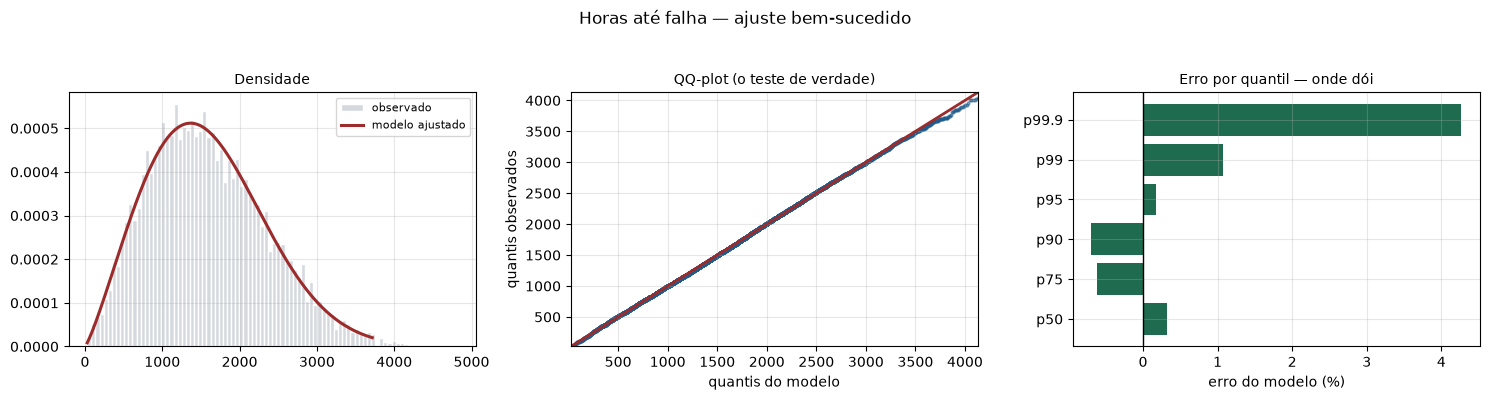

,quantil,observado,modelo,erro %
0,p50,1515.30,1520.09,0.32
1,p75,2093.73,2080.84,-0.62
2,p90,2636.82,2618.57,-0.69
3,p95,2945.13,2950.10,0.17
4,p99,3546.30,3584.53,1.08
5,p99.9,4130.87,4307.28,4.27


In [5]:
def critica_ajuste(amostra, dist, params, titulo):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

    # Painel 1: densidade ajustada sobre o histograma
    grade = np.linspace(amostra.min(), np.percentile(amostra, 99.5), 400)
    axes[0].hist(amostra, bins=90, density=True, color="#D5D9DE",
                 edgecolor="white", label="observado")
    axes[0].plot(grade, dist.pdf(grade, *params), lw=2.2, color=VERMELHO,
                 label="modelo ajustado")
    axes[0].set_title("Densidade", fontsize=10)
    axes[0].legend(fontsize=8)

    # Painel 2: QQ-plot — o diagnóstico que realmente importa
    p = (np.arange(1, len(amostra) + 1) - 0.5) / len(amostra)
    q_teorico = dist.ppf(p, *params)
    q_observado = np.sort(amostra)
    axes[1].scatter(q_teorico, q_observado, s=4, color=AZUL, alpha=0.5)
    lim = [min(q_teorico[0], q_observado[0]), np.percentile(q_observado, 99.9)]
    axes[1].plot(lim, lim, lw=2, color=VERMELHO)
    axes[1].set_xlim(lim)
    axes[1].set_ylim(lim)
    axes[1].set_xlabel("quantis do modelo")
    axes[1].set_ylabel("quantis observados")
    axes[1].set_title("QQ-plot (o teste de verdade)", fontsize=10)

    # Painel 3: erro nos quantis que importam para SLA / risco
    quantis = np.array([0.50, 0.75, 0.90, 0.95, 0.99, 0.999])
    obs = np.quantile(amostra, quantis)
    mod = dist.ppf(quantis, *params)
    erro_rel = (mod - obs) / obs
    cores = [VERDE if abs(e) < 0.05 else AMBAR if abs(e) < 0.15 else VERMELHO
             for e in erro_rel]
    axes[2].barh([f"p{q*100:g}" for q in quantis], erro_rel * 100, color=cores)
    axes[2].axvline(0, color="black", lw=1)
    axes[2].set_xlabel("erro do modelo (%)")
    axes[2].set_title("Erro por quantil — onde dói", fontsize=10)

    plt.suptitle(titulo, y=1.04, fontsize=12)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame({"quantil": [f"p{q*100:g}" for q in quantis],
                         "observado": obs, "modelo": mod,
                         "erro %": erro_rel * 100})


melhor = tab_falha.iloc[0]
dist_falha = continuas[melhor["distribuição"]]
print(f"Melhor modelo para 'Horas até falha': {melhor['distribuição']}")
critica_ajuste(falha, dist_falha, dist_falha.fit(falha, floc=0),
               "Horas até falha — ajuste bem-sucedido").round(2)

Este é o retrato de um **bom** ajuste: QQ-plot na diagonal e erros por quantil
abaixo de poucos por cento, inclusive no p99,9.

Agora o caso interessante — a latência, que **não** é uma distribuição simples.

Melhor modelo simples para 'Latência': Log-normal


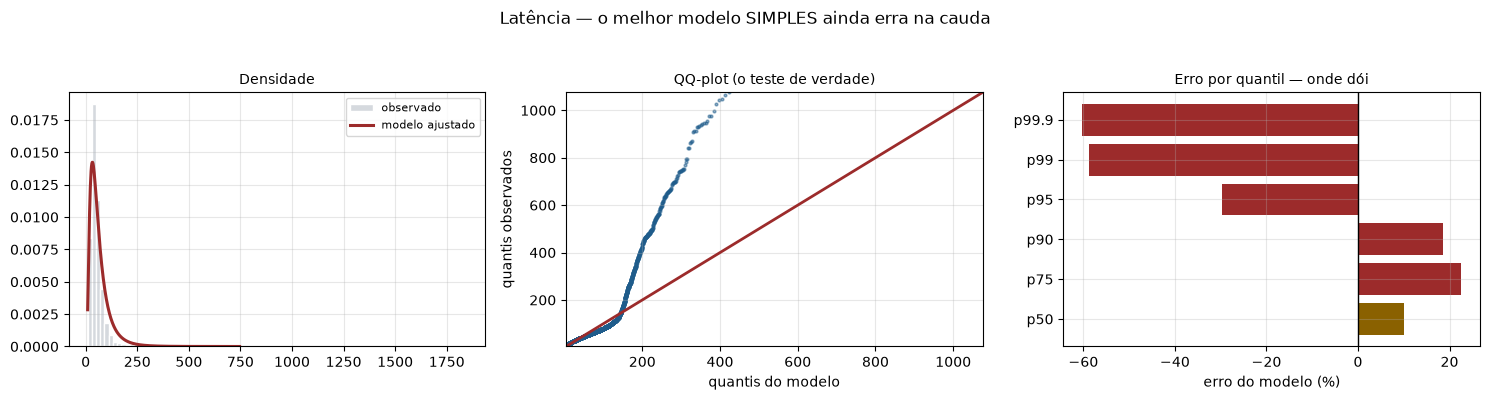

,quantil,observado,modelo,erro %
0,p50,47.06,51.77,10.02
1,p75,67.00,82.09,22.52
2,p90,104.85,124.29,18.55
3,p95,226.89,159.32,-29.78
4,p99,616.70,253.81,-58.84
5,p99.9,1075.86,427.77,-60.24


In [6]:
melhor_lat = tab_latencia.iloc[0]
dist_lat = continuas[melhor_lat["distribuição"]]
print(f"Melhor modelo simples para 'Latência': {melhor_lat['distribuição']}")
critica_ajuste(latencia, dist_lat, dist_lat.fit(latencia, floc=0),
               "Latência — o melhor modelo SIMPLES ainda erra na cauda").round(2)

Olhe a barra do **p99,9**. O AIC elegeu essa distribuição como a melhor entre
as candidatas, e ainda assim ela erra o quantil que define o SLA.

É o caso clássico em que o modelo certo é uma **mistura**: 93% das requisições
seguem um regime rápido e 7% um regime lento. Vamos ajustar a mistura.

In [7]:
def ajusta_mistura_lognormal(amostra, n_iter=200, semente=0):
    """EM (Expectation-Maximization) para mistura de 2 log-normais.

    A ideia do EM em uma frase: se soubéssemos a qual componente cada ponto
    pertence, ajustar seria trivial; se soubéssemos os parâmetros, saberíamos a
    quem cada ponto pertence. Como não sabemos nenhum dos dois, alternamos entre
    os dois passos até convergir.
    """
    y = np.log(amostra)
    r = np.random.default_rng(semente)
    # Chute inicial: divide pela mediana
    mu = np.array([np.percentile(y, 30), np.percentile(y, 80)])
    sigma = np.array([y.std() / 2, y.std() / 2])
    peso = np.array([0.5, 0.5])

    for _ in range(n_iter):
        # Passo E: responsabilidade de cada componente por cada ponto
        dens = np.stack([peso[j] * stats.norm.pdf(y, mu[j], sigma[j])
                         for j in range(2)])
        resp = dens / dens.sum(axis=0, keepdims=True)
        # Passo M: reestima os parâmetros ponderando pelas responsabilidades
        nk = resp.sum(axis=1)
        peso = nk / len(y)
        mu = (resp * y).sum(axis=1) / nk
        sigma = np.sqrt((resp * (y - mu[:, None]) ** 2).sum(axis=1) / nk)
    return peso, mu, sigma


peso, mu_m, sigma_m = ajusta_mistura_lognormal(latencia)
ordem = np.argsort(mu_m)
peso, mu_m, sigma_m = peso[ordem], mu_m[ordem], sigma_m[ordem]

print("Mistura de 2 log-normais ajustada por EM:")
for j in range(2):
    print(f"   componente {j+1}: peso = {peso[j]:.3f}  "
          f"mediana = {np.exp(mu_m[j]):7.1f} ms  σ_log = {sigma_m[j]:.3f}")
print("\n(Compare com o mecanismo gerador: 93% em ~45 ms, 7% em ~320 ms)")


def cdf_mistura(x):
    return sum(peso[j] * stats.norm.cdf(np.log(x), mu_m[j], sigma_m[j])
               for j in range(2))

def ppf_mistura(p, lo=1e-3, hi=1e5):
    """Quantil da mistura por busca binária sobre a CDF (que é monotônica)."""
    p = np.atleast_1d(p)
    baixo = np.full_like(p, lo, dtype=float)
    alto = np.full_like(p, hi, dtype=float)
    for _ in range(80):
        meio = (baixo + alto) / 2
        maior = cdf_mistura(meio) < p
        baixo = np.where(maior, meio, baixo)
        alto = np.where(maior, alto, meio)
    return (baixo + alto) / 2


quantis = np.array([0.50, 0.90, 0.95, 0.99, 0.999])
obs = np.quantile(latencia, quantis)
simples = dist_lat.ppf(quantis, *dist_lat.fit(latencia, floc=0))
mist = ppf_mistura(quantis)

resultado = pd.DataFrame({
    "quantil": [f"p{q*100:g}" for q in quantis],
    "observado (ms)": obs,
    f"{melhor_lat['distribuição']} (ms)": simples,
    "mistura (ms)": mist,
    "erro simples %": (simples - obs) / obs * 100,
    "erro mistura %": (mist - obs) / obs * 100,
})
print()
print(resultado.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

Mistura de 2 log-normais ajustada por EM:
   componente 1: peso = 0.934  mediana =    45.3 ms  σ_log = 0.458
   componente 2: peso = 0.066  mediana =   335.5 ms  σ_log = 0.579

(Compare com o mecanismo gerador: 93% em ~45 ms, 7% em ~320 ms)

quantil  observado (ms)  Log-normal (ms)  mistura (ms)  erro simples %  erro mistura %
    p50           47.06            51.77         47.21           10.02            0.33
    p90          104.85           124.29        102.55           18.55           -2.19
    p95          226.89           159.32        227.37          -29.78            0.21
    p99          616.70           253.81        610.86          -58.84           -0.95
  p99.9        1,075.86           427.77      1,178.43          -60.24            9.53


A mistura recupera os parâmetros do mecanismo gerador e reduz drasticamente o
erro nos quantis altos — os que definem o SLA.

> **No mercado:** latência com dois regimes é a regra, não a exceção (cache
> hit vs. miss, conexão quente vs. fria, com e sem retry). Modelar como uma
> única distribuição sempre subestima a cauda, e subestimar a cauda é
> dimensionar infraestrutura de menos.

## 5. Dados de contagem: o caminho é outro

Para contagens não se usa `.fit()` de distribuição contínua. O diagnóstico
começa pela razão variância/média.

Chamados por cliente — média = 1.986, variância = 6.834
Razão Var/média = 3.441  ->  SUPERDISPERSO: Poisson não serve
% de zeros observada = 36.7%
% de zeros que uma Poisson(1.986) preveria = 13.7%


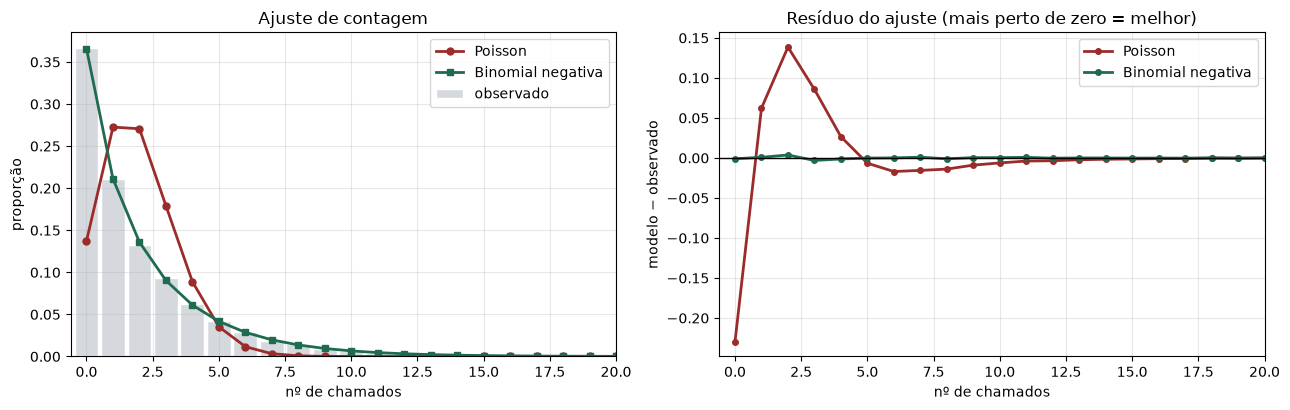

Poisson              erro absoluto total = 0.6260
Binomial negativa    erro absoluto total = 0.0152


In [8]:
v = chamados
razao = v.var(ddof=1) / v.mean()
print(f"Chamados por cliente — média = {v.mean():.3f}, variância = {v.var(ddof=1):.3f}")
print(f"Razão Var/média = {razao:.3f}  ->  ", end="")
print("Poisson plausível" if 0.8 < razao < 1.25 else "SUPERDISPERSO: Poisson não serve")
print(f"% de zeros observada = {(v == 0).mean():.1%}")
print(f"% de zeros que uma Poisson({v.mean():.3f}) preveria = "
      f"{stats.poisson.pmf(0, v.mean()):.1%}")

# Ajuste por momentos e por verossimilhança
mu_c, s2_c = v.mean(), v.var(ddof=1)
r_mom = mu_c ** 2 / (s2_c - mu_c)
p_mom = r_mom / (r_mom + mu_c)

k = np.arange(0, v.max() + 1)
obs_freq = np.array([(v == i).mean() for i in k])

modelos_cont = {
    "Poisson": stats.poisson.pmf(k, mu_c),
    "Binomial negativa": stats.nbinom.pmf(k, r_mom, p_mom),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
largura = 0.9
ax1.bar(k, obs_freq, width=largura, color="#D5D9DE", edgecolor="white",
        label="observado")
for (nome, pmf), cor, marca in zip(modelos_cont.items(), [VERMELHO, VERDE], ["o", "s"]):
    ax1.plot(k, pmf, marca + "-", lw=2, ms=5, color=cor, label=nome)
ax1.set_xlim(-0.6, min(v.max(), 20))
ax1.set_xlabel("nº de chamados")
ax1.set_ylabel("proporção")
ax1.set_title("Ajuste de contagem")
ax1.legend()

for (nome, pmf), cor in zip(modelos_cont.items(), [VERMELHO, VERDE]):
    ax2.plot(k, pmf - obs_freq, "o-", lw=2, ms=4, color=cor, label=nome)
ax2.axhline(0, color="black", lw=1)
ax2.set_xlim(-0.6, min(v.max(), 20))
ax2.set_xlabel("nº de chamados")
ax2.set_ylabel("modelo − observado")
ax2.set_title("Resíduo do ajuste (mais perto de zero = melhor)")
ax2.legend()
plt.tight_layout()
plt.show()

for nome, pmf in modelos_cont.items():
    print(f"{nome:20s} erro absoluto total = {np.abs(pmf - obs_freq).sum():.4f}")

## 6. Protocolo final — o que levar para o trabalho

1. **Classifique**: contínua ou contagem? Positiva ou pode ser negativa?
   Limitada ou ilimitada?
2. **Olhe** em três escalas: natural, log e ECDF.
3. Para contagens, calcule **Var/média** antes de qualquer coisa.
4. Ajuste 3–5 candidatas por MLE e ranqueie por **AIC**.
5. **Critique com QQ-plot** e com erro por quantil — o AIC não vê a cauda.
6. Se nenhuma candidata simples serve, considere **mistura**, **inflação de
   zeros** ou modelagem separada da cauda.
7. Documente a decisão e o erro residual nos quantis que a sua decisão usa.

> **Sobre testes de aderência (KS, Anderson-Darling, qui-quadrado):** com
> $n$ grande eles **sempre** rejeitam, pelo mesmo motivo que os testes de
> normalidade sempre rejeitam. Reporte a **estatística** (que é uma medida de
> distância) e não o p-valor. Um KS de 0,008 com $n = 100.000$ é um ajuste
> excelente, ainda que o p-valor seja 0,000.

## 7. Exercícios

1. Aumente a proporção do regime lento da latência de 7% para 25%. O AIC ainda
   elege a mesma distribuição simples? E o QQ-plot, denuncia mais cedo?
2. Implemente o critério **BIC** ($k\ln n - 2\ln\hat{L}$) e compare o ranking
   com o do AIC. Em que situação eles discordam? (Dica: o BIC pune mais
   complexidade quando $n$ é grande.)
3. Gere dados **zero-inflados** e ajuste: (a) Poisson, (b) binomial negativa,
   (c) Poisson zero-inflada. Compare pelos resíduos da seção 5.
4. Pegue um conjunto de dados real seu (ou o dataset `california_housing` do
   scikit-learn) e aplique o protocolo completo à variável alvo. Documente cada
   uma das 7 etapas.

## Próximo módulo

`03-inferencia-e-estimacao/` — como estimar parâmetros com honestidade sobre a
incerteza, e o que exatamente um intervalo de confiança promete.